In [3]:
!pip install transformers datasets scikit-learn pandas numpy gradio

In [1]:
!pip uninstall torch -y
!pip install torch --index-url https://download.pytorch.org/whl/cpu

Found existing installation: torch 2.12.1
Uninstalling torch-2.12.1:
  Successfully uninstalled torch-2.12.1
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached torch-2.12.1%2Bcpu-cp314-cp314-win_amd64.whl.metadata (32 kB)
Using cached torch-2.12.1%2Bcpu-cp314-cp314-win_amd64.whl (124.9 MB)


In [2]:
import pandas as pd
import numpy as np
from transformers import pipeline
import gradio as gr
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

C:\Users\Kamil Computers\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported!


In [3]:
# Sample support tickets dataset
tickets = [
    {"ticket": "My internet connection keeps dropping every few minutes", "true_tag": "Network"},
    {"ticket": "I cannot login to my account, forgot my password", "true_tag": "Account"},
    {"ticket": "The app crashes whenever I try to upload a file", "true_tag": "Bug"},
    {"ticket": "I was charged twice for my monthly subscription", "true_tag": "Billing"},
    {"ticket": "How do I export my data to Excel format?", "true_tag": "How-To"},
    {"ticket": "My WiFi router is not connecting to the server", "true_tag": "Network"},
    {"ticket": "Please cancel my subscription and issue a refund", "true_tag": "Billing"},
    {"ticket": "The login button does not work on mobile browser", "true_tag": "Bug"},
    {"ticket": "How do I change my email address in settings?", "true_tag": "How-To"},
    {"ticket": "My account has been locked after failed login attempts", "true_tag": "Account"},
    {"ticket": "I received an incorrect invoice for last month", "true_tag": "Billing"},
    {"ticket": "The video call feature is not working properly", "true_tag": "Bug"},
    {"ticket": "How do I add a new user to my team account?", "true_tag": "How-To"},
    {"ticket": "Slow internet speeds during peak hours", "true_tag": "Network"},
    {"ticket": "I need to update my credit card information", "true_tag": "Billing"},
]

df = pd.DataFrame(tickets)
print("Total tickets:", len(df))
print(df.head())

Total tickets: 15
                                              ticket true_tag
0  My internet connection keeps dropping every fe...  Network
1   I cannot login to my account, forgot my password  Account
2    The app crashes whenever I try to upload a file      Bug
3    I was charged twice for my monthly subscription  Billing
4           How do I export my data to Excel format?   How-To


In [8]:
# Define possible tags
tags = ["Network", "Account", "Bug", "Billing", "How-To"]

print("Loading zero-shot classifier... (2-3 mins first time)")
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)
print("Classifier loaded!")

Loading zero-shot classifier... (2-3 mins first time)


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 1376.98it/s]


Classifier loaded!


In [9]:
def get_top3_tags(ticket_text):
    result = classifier(ticket_text, candidate_labels=tags)
    top3 = list(zip(result['labels'][:3], result['scores'][:3]))
    return top3

# Test on one ticket
sample = "My internet is very slow and keeps disconnecting"
top3 = get_top3_tags(sample)
print(f"Ticket: {sample}")
print("Top 3 Tags:")
for tag, score in top3:
    print(f"  {tag}: {score:.2%}")

Ticket: My internet is very slow and keeps disconnecting
Top 3 Tags:
  Account: 35.66%
  Network: 28.79%
  Bug: 14.82%


In [10]:
print("Running zero-shot on all tickets...")

zero_shot_results = []
for _, row in df.iterrows():
    top3 = get_top3_tags(row['ticket'])
    predicted_tag = top3[0][0]  # top 1 prediction
    zero_shot_results.append({
        "ticket": row['ticket'],
        "true_tag": row['true_tag'],
        "predicted_tag": predicted_tag,
        "top3_tags": [t[0] for t in top3],
        "top3_scores": [round(t[1], 3) for t in top3],
        "correct": predicted_tag == row['true_tag']
    })

results_df = pd.DataFrame(zero_shot_results)
accuracy = results_df['correct'].mean()
print(f"\nZero-Shot Accuracy: {accuracy:.2%}")
print(results_df[['ticket', 'true_tag', 'predicted_tag', 'correct']].to_string())

Running zero-shot on all tickets...

Zero-Shot Accuracy: 73.33%
                                                     ticket true_tag predicted_tag  correct
0   My internet connection keeps dropping every few minutes  Network       Network     True
1          I cannot login to my account, forgot my password  Account       Account     True
2           The app crashes whenever I try to upload a file      Bug           Bug     True
3           I was charged twice for my monthly subscription  Billing       Account    False
4                  How do I export my data to Excel format?   How-To        How-To     True
5            My WiFi router is not connecting to the server  Network       Network     True
6          Please cancel my subscription and issue a refund  Billing       Account    False
7          The login button does not work on mobile browser      Bug           Bug     True
8             How do I change my email address in settings?   How-To        How-To     True
9    My account 

In [11]:
def get_top3_tags_fewshot(ticket_text):
    # Add examples to help the model (few-shot)
    prompt = f"""Examples:
- "internet drops every few minutes" → Network
- "cannot login, forgot password" → Account  
- "app crashes on file upload" → Bug
- "charged twice for subscription" → Billing
- "how do I export to Excel" → How-To

Now classify this ticket: {ticket_text}"""

    result = classifier(prompt, candidate_labels=tags)
    top3 = list(zip(result['labels'][:3], result['scores'][:3]))
    return top3

# Test few-shot
sample = "My internet is very slow and keeps disconnecting"
top3 = get_top3_tags_fewshot(sample)
print(f"Ticket: {sample}")
print("Top 3 Tags (Few-Shot):")
for tag, score in top3:
    print(f"  {tag}: {score:.2%}")

Ticket: My internet is very slow and keeps disconnecting
Top 3 Tags (Few-Shot):
  Network: 66.21%
  Account: 14.83%
  Bug: 11.43%


In [15]:
print("Running few-shot on all tickets...")

fewshot_results = []
for _, row in df.iterrows():
    top3 = get_top3_tags_fewshot(row['ticket'])
    predicted_tag = top3[0][0]
    fewshot_results.append({
        "predicted_tag": predicted_tag,
        "correct": predicted_tag == row['true_tag']
    })

fewshot_df = pd.DataFrame(fewshot_results)
fewshot_accuracy = fewshot_df['correct'].mean()

print(f"\n{'='*40}")
print(f"Zero-Shot  Accuracy: {accuracy:.2%}")
print(f"Few-Shot   Accuracy: {fewshot_accuracy:.2%}")
print(f"{'='*40}")
print(f"Improvement: {(fewshot_accuracy - accuracy):.2%}")

Running few-shot on all tickets...

Zero-Shot  Accuracy: 73.33%
Few-Shot   Accuracy: 60.00%
Improvement: -13.33%


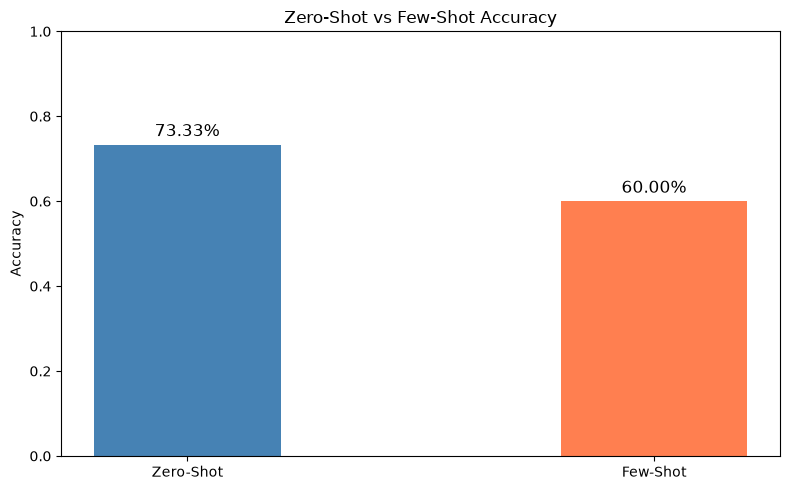

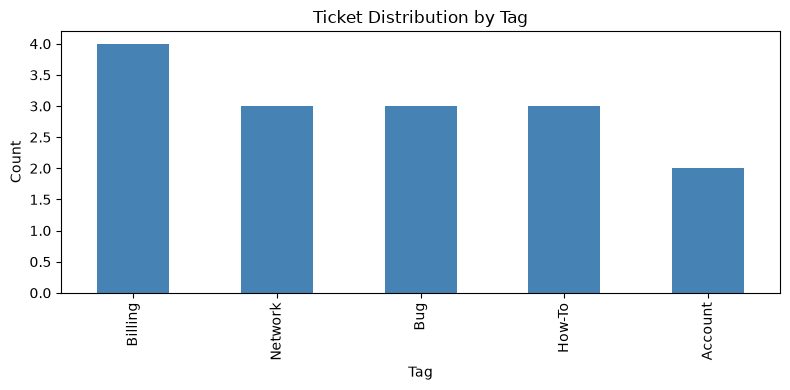

Charts saved!


In [16]:
import matplotlib.pyplot as plt

# Accuracy comparison chart
methods = ['Zero-Shot', 'Few-Shot']
accuracies = [accuracy, fewshot_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, accuracies, color=['steelblue', 'coral'], width=0.4)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Zero-Shot vs Few-Shot Accuracy")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{acc:.2%}", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("accuracy_comparison.png")
plt.show()

# Tag distribution chart
results_df['true_tag'].value_counts().plot(
    kind='bar', color='steelblue', figsize=(8,4)
)
plt.title("Ticket Distribution by Tag")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("tag_distribution.png")
plt.show()
print("Charts saved!")

In [17]:
def tag_ticket(ticket_text):
    top3_zero = get_top3_tags(ticket_text)
    top3_few  = get_top3_tags_fewshot(ticket_text)

    output = "🔵 ZERO-SHOT Results:\n"
    for i, (tag, score) in enumerate(top3_zero):
        output += f"  #{i+1} {tag}: {score:.2%}\n"

    output += "\n🟠 FEW-SHOT Results:\n"
    for i, (tag, score) in enumerate(top3_few):
        output += f"  #{i+1} {tag}: {score:.2%}\n"

    return output

demo = gr.Interface(
    fn=tag_ticket,
    inputs=gr.Textbox(
        placeholder="Enter a support ticket here...",
        label="Support Ticket"
    ),
    outputs=gr.Textbox(label="Predicted Tags (Top 3)"),
    title="🎫 Auto Support Ticket Tagger",
    description="Automatically tags support tickets using Zero-Shot and Few-Shot LLM",
    examples=[
        ["My internet keeps disconnecting every hour"],
        ["I was billed twice this month, please refund"],
        ["The app crashes when I open it on my phone"],
        ["How do I reset my password?"],
    ]
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv
